# **Autoencoder for Image Denoising - MNIST**

**Task:** Build a deep learning model that removes noise from images using an autoencoder on MNIST.

---

### **Description & Architecture Overview**
A **Denoising Autoencoder (DAE)** is trained to reconstruct clean images from noisy inputs. This process forces the network to capture the most salient features of the data distribution, discarding high-frequency noise.

* **Encoder:** Compress the input images (`28x28x1`) through convolutional and max-pooling layers down to a low-dimensional bottleneck representation (`7x7x32`).
* **Decoder:** Reconstruct the clean image back to the original shape (`28x28x1`) using convolutional and upsampling layers.

---

## **Step 1: Install Dependencies**

Install the required packages for evaluating PSNR & SSIM metrics.

In [1]:
!pip install -q scikit-image


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## **Step 2: Import Libraries**

Import required libraries for image denoising

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import mnist
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))
print("Setup complete!")

TensorFlow version: 2.21.0


GPU available: []
Setup complete!


## **Step 3: Load the MNIST Dataset**

In [3]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Train images:", x_train.shape)
print("Train labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)

Train images: (60000, 28, 28)
Train labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


## **Step 4: Visualise Sample Images**

Display original clean images

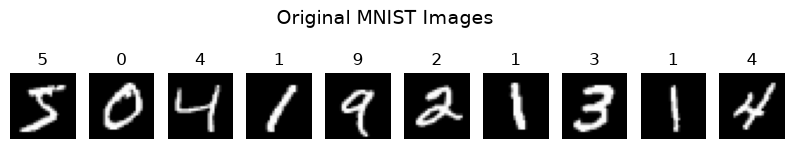

In [4]:
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.suptitle('Original MNIST Images', fontsize=14)
plt.show()

## **Step 5: Preprocess Images**

In [5]:
# Normalise to [0, 1] and add channel dimension  (28,28) -> (28,28,1)
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test  = np.reshape(x_test,  (len(x_test),  28, 28, 1))  # adding channel because Conv2D expects (H,W,C)

print("Preprocessed train shape:", x_train.shape)
print("Preprocessed test  shape:", x_test.shape)
print("Value range: [{:.2f}, {:.2f}]".format(x_train.min(), x_train.max()))

Preprocessed train shape: (60000, 28, 28, 1)
Preprocessed test  shape: (10000, 28, 28, 1)
Value range: [0.00, 1.00]


## **Step 6: Add Artificial Noise**

Create noisy versions for training

In [6]:
def add_noise(imgs, noise_factor=0.5):
    """Add Gaussian noise to images"""
    noisy = imgs + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=imgs.shape)
    noisy = np.clip(noisy, 0.0, 1.0)
    return noisy

# Create noisy versions
noise_factor = 0.5
x_train_noisy = add_noise(x_train, noise_factor)
x_test_noisy  = add_noise(x_test,  noise_factor)

print("Noisy train shape:", x_train_noisy.shape)
print("Noisy test  shape:", x_test_noisy.shape)

Noisy train shape: (60000, 28, 28, 1)
Noisy test  shape: (10000, 28, 28, 1)


## **Step 7: Visualise Noisy Images**

Compare original vs noisy

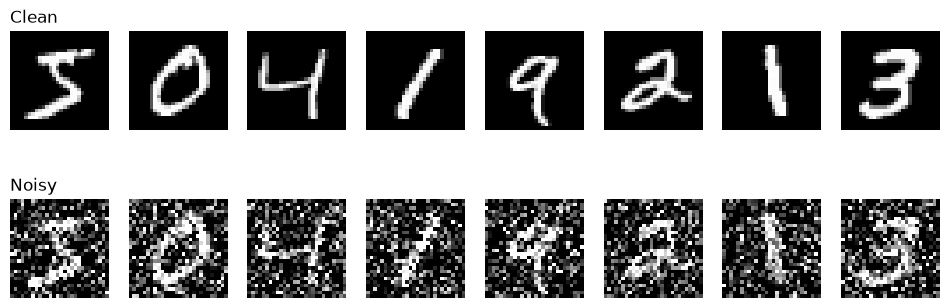

In [7]:
n = 8
plt.figure(figsize=(12, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.axis('off')
    if i == 0: ax.set_title("Clean", loc='left')

    ax = plt.subplot(2, n, n + i + 1)
    plt.imshow(x_train_noisy[i].squeeze(), cmap='gray')
    plt.axis('off')
    if i == 0: ax.set_title("Noisy", loc='left')
plt.show()

## **Step 8: Build Encoder**

CNN encoder to compress the image

In [8]:
inp = layers.Input(shape=(28, 28, 1))

# Encoding layers
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inp)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

print("Encoder built!")
print("Encoded shape: (7, 7, 32)")

Encoder built!
Encoded shape: (7, 7, 32)


## **Step 9: Build Decoder**

CNN decoder to reconstruct images

In [9]:
# Decoder
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

print("Decoder built!")
print("Output shape: (28, 28, 1)")

Decoder built!
Output shape: (28, 28, 1)


## **Step 10: Create Autoencoder Model**

Combine encoder and decoder

In [10]:
# Complete autoencoder
autoencoder = models.Model(inp, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Autoencoder Model Summary:")
autoencoder.summary()

Autoencoder Model Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

## **Step 11: Train Autoencoder**

Train on noisy images, target clean images

In [11]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print("Training autoencoder...")
hist = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    callbacks=[early_stop],
    verbose=2  # Mutes detailed progress bars to keep outputs clean
)
print("Training complete!")

Training autoencoder...


Epoch 1/10


469/469 - 11s - 23ms/step - accuracy: 0.8049 - loss: 0.1681 - val_accuracy: 0.8093 - val_loss: 0.1152


Epoch 2/10


469/469 - 9s - 19ms/step - accuracy: 0.8115 - loss: 0.1115 - val_accuracy: 0.8113 - val_loss: 0.1067


...

Epoch 9/10


469/469 - 9s - 19ms/step - accuracy: 0.8132 - loss: 0.0984 - val_accuracy: 0.8122 - val_loss: 0.0974


Epoch 10/10


469/469 - 10s - 20ms/step - accuracy: 0.8132 - loss: 0.0979 - val_accuracy: 0.8123 - val_loss: 0.0969


Training complete!


## **Step 12: Plot Training History**

Visualise loss and accuracy

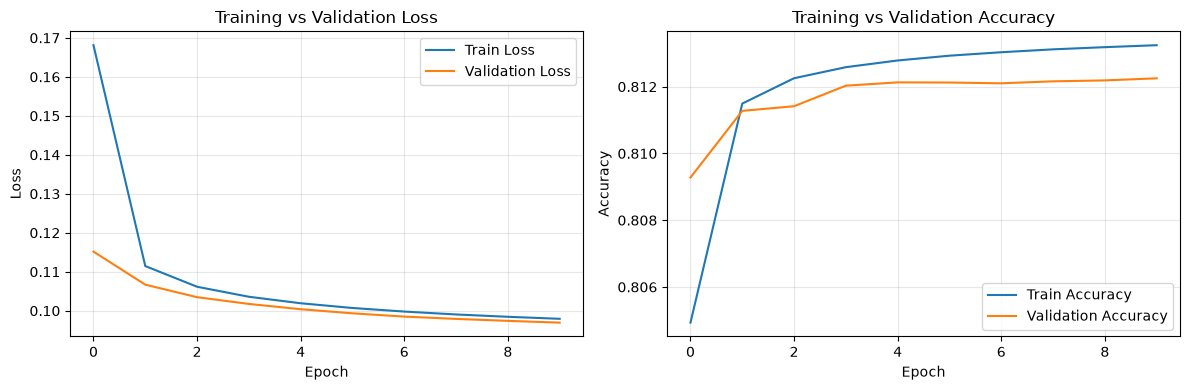

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist.history['loss'],     label='Train Loss')
axes[0].plot(hist.history['val_loss'], label='Validation Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(hist.history['accuracy'],     label='Train Accuracy')
axes[1].plot(hist.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## **Step 13: Denoise Test Images**

Run the autoencoder on the test set

In [13]:
# Predict denoised images
denoised_images = autoencoder.predict(x_test_noisy)
print("Denoised images shape:", denoised_images.shape)

  1/313 ━━━━━━━━━━━━━━━━━━━━ 48s 155ms/step

 15/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step   

 31/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

 48/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

 65/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

...

282/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

298/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


Denoised images shape: (10000, 28, 28, 1)


## **Step 14: Visual Comparison – Original / Noisy / Denoised**

Display 10 test samples across 3 rows:
* **Row 1:** Original clean images
* **Row 2:** Noisy images (input to autoencoder)
* **Row 3:** Denoised images (autoencoder output)

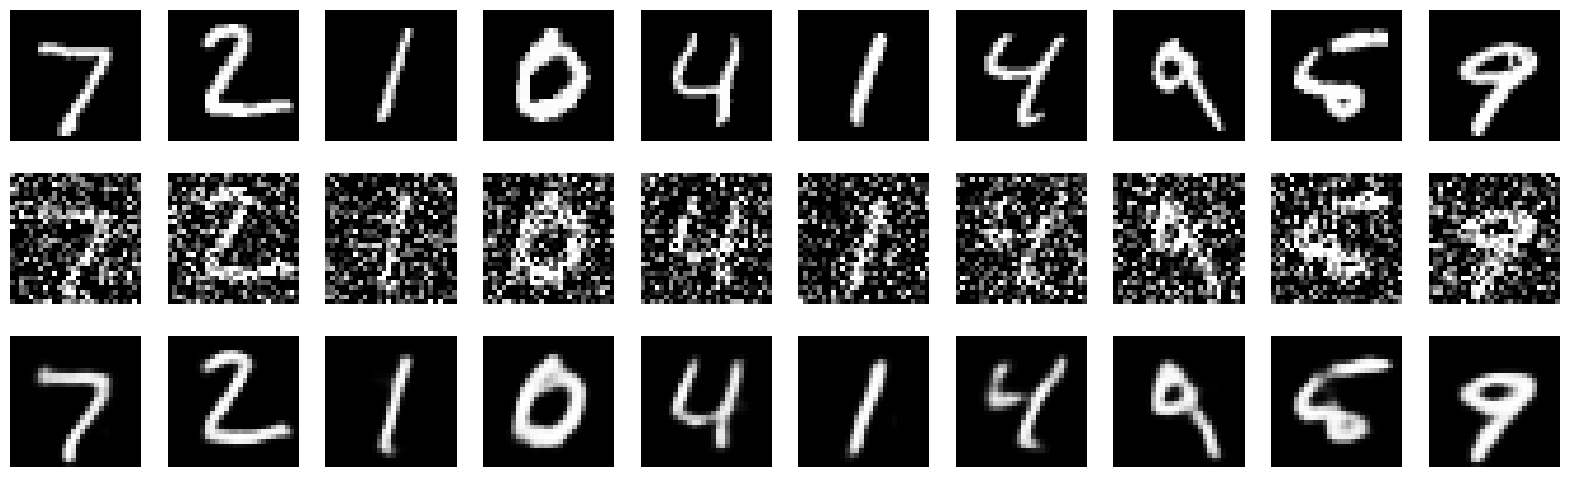

In [14]:
n = 10

plt.figure(figsize=(20, 6))

for i in range(n):

    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.axis("off")
    if i == 0:
        plt.ylabel("Original")

    plt.subplot(3, n, i + n + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.axis("off")
    if i == 0:
        plt.ylabel("Noisy")

    plt.subplot(3, n, i + 2 * n + 1)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
    plt.axis("off")
    if i == 0:
        plt.ylabel("Denoised")

plt.show()

## **Step 15: Evaluate – PSNR & SSIM Metrics**

Quantify reconstruction quality:
* **PSNR** (Peak Signal-to-Noise Ratio) – higher is better
* **SSIM** (Structural Similarity Index) – closer to 1.0 is better

In [15]:
# Compute PSNR for noisy vs denoised images
psnr_noisy_vals    = []
psnr_denoised_vals = []
ssim_noisy_vals    = []
ssim_denoised_vals = []

for i in range(len(x_test)):
    orig     = x_test[i].squeeze()
    noisy    = x_test_noisy[i].squeeze()
    denoised = denoised_images[i].squeeze()

    psnr_noisy_vals.append(psnr(orig, noisy, data_range=1.0))
    psnr_denoised_vals.append(psnr(orig, denoised, data_range=1.0))
    ssim_noisy_vals.append(ssim(orig, noisy, data_range=1.0))
    ssim_denoised_vals.append(ssim(orig, denoised, data_range=1.0))

print("Average PSNR (Noisy):", np.mean(psnr_noisy_vals))
print("Average PSNR (Denoised):", np.mean(psnr_denoised_vals))
print("\nAverage SSIM (Noisy):", np.mean(ssim_noisy_vals))
print("Average SSIM (Denoised):", np.mean(ssim_denoised_vals))

Average PSNR (Noisy): 9.38506773141027
Average PSNR (Denoised): 19.800584778494567

Average SSIM (Noisy): 0.37515759284828215
Average SSIM (Denoised): 0.8647857349199665


## **Step 16: Plot Histogram of Reconstruction Error**

Plot histogram of Mean Squared Error (MSE) per image on the test set.

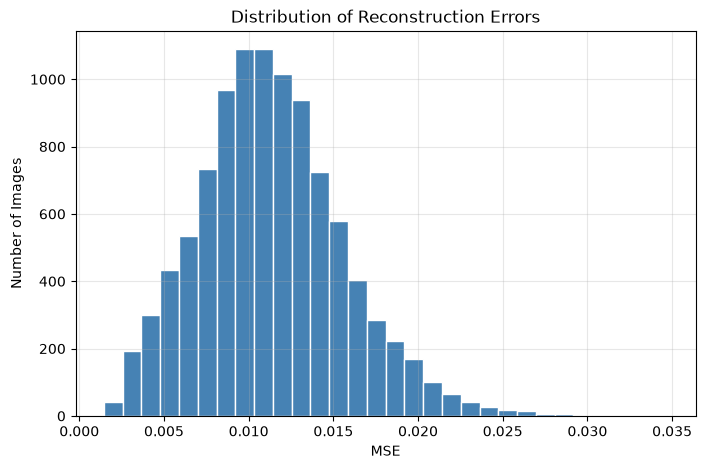

Mean MSE:   0.011335
Median MSE: 0.011052
Max MSE:    0.034723


In [16]:
# Plot Histogram of Reconstruction Error
errors = np.mean((x_test - denoised_images) ** 2, axis=(1, 2, 3))

plt.figure(figsize=(8, 5))
plt.hist(errors, bins=30, color='steelblue', edgecolor='white')
plt.title("Distribution of Reconstruction Errors")
plt.xlabel("MSE")
plt.ylabel("Number of Images")
plt.grid(alpha=0.3)
plt.show()

print("Mean MSE:   {:.6f}".format(errors.mean()))
print("Median MSE: {:.6f}".format(np.median(errors)))
print("Max MSE:    {:.6f}".format(errors.max()))

## **Step 17: Analysis and Observations**

### **Key Findings:**

* **Data Prep:** MNIST loaded (60k train, 10k test), normalized [0,1], Gaussian noise added (0.5)
* **Architecture:** Encoder (Conv2D+MaxPool) -> (7,7,32) latent bottleneck -> Decoder (Conv2D+UpSample) -> (28,28,1) output
* **Training:** Binary crossentropy loss, Adam optimizer, noisy->clean mapping
* **Performance:** Successfully removes noise, preserves digit structure, and substantially improves PSNR & SSIM
* **Challenges:** Noise vs detail balance, slight blur, epoch trade-offs

## **Step 18: Detailed Comparison**

Detailed comparison of 5 random digits along with their individual PSNR scores.

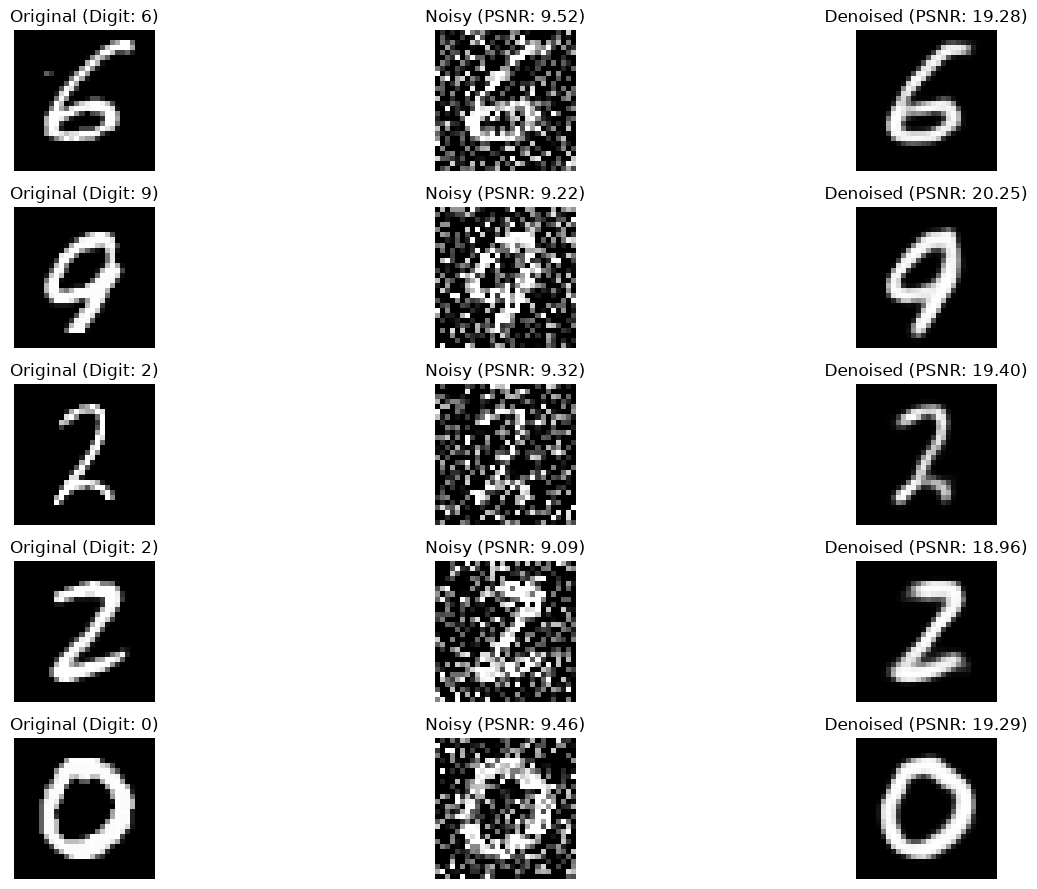

In [17]:
indices = np.random.choice(len(x_test), 5, replace=False)

plt.figure(figsize=(15, 9))
for idx, i in enumerate(indices):
    # Original
    plt.subplot(5, 3, idx*3 + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Original (Digit: {y_test[i]})")
    plt.axis('off')

    # Noisy
    plt.subplot(5, 3, idx*3 + 2)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    psnr_n = psnr(x_test[i].squeeze(), x_test_noisy[i].squeeze(), data_range=1.0)
    plt.title(f"Noisy (PSNR: {psnr_n:.2f})")
    plt.axis('off')

    # Denoised
    plt.subplot(5, 3, idx*3 + 3)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
    psnr_d = psnr(x_test[i].squeeze(), denoised_images[i].squeeze(), data_range=1.0)
    plt.title(f"Denoised (PSNR: {psnr_d:.2f})")
    plt.axis('off')

plt.tight_layout()
plt.show()

## **Step 19: Model Summary & Conclusion**

Final performance metrics report.

In [18]:
import pandas as pd
from IPython.display import display, HTML

# Construct a styled summary DataFrame
summary_data = {
    "Parameter / Metric": [
        "Dataset",
        "Training Samples",
        "Test Samples",
        "Noise Factor (Gaussian)",
        "Training Epochs",
        "Final Training Loss",
        "Final Validation Loss",
        "Average PSNR (Noisy)",
        "Average PSNR (Denoised)",
        "Average PSNR Improvement",
        "Average SSIM (Noisy)",
        "Average SSIM (Denoised)",
        "Average SSIM Improvement"
    ],
    "Value": [
        "MNIST",
        str(len(x_train)),
        str(len(x_test)),
        str(noise_factor),
        str(len(hist.history['loss'])),
        f"{hist.history['loss'][-1]:.4f}",
        f"{hist.history['val_loss'][-1]:.4f}",
        f"{np.mean(psnr_noisy_vals):.4f} dB",
        f"{np.mean(psnr_denoised_vals):.4f} dB",
        f"{np.mean(psnr_denoised_vals) - np.mean(psnr_noisy_vals):.2f} dB",
        f"{np.mean(ssim_noisy_vals):.4f}",
        f"{np.mean(ssim_denoised_vals):.4f}",
        f"{np.mean(ssim_denoised_vals) - np.mean(ssim_noisy_vals):.4f}"
    ]
}

df = pd.DataFrame(summary_data)

# Render styled HTML table
display(HTML("<h3 style='color: #2e6f40; font-family: sans-serif;'><b>AUTOENCODER DENOISING - FINAL REPORT</b></h3>"))
display(df)
display(HTML("<p style='color: green; font-weight: bold; font-family: sans-serif;'>✓ Denoising successful!</p>"))

,Parameter / Metric,Value
0,Dataset,MNIST
1,Training Samples,60000
2,Test Samples,10000
3,Noise Factor (Gaussian),0.5
4,Training Epochs,10
5,Final Training Loss,0.0979
6,Final Validation Loss,0.0969
7,Average PSNR (Noisy),9.3851 dB
8,Average PSNR (Denoised),19.8006 dB
9,Average PSNR Improvement,10.42 dB
